# Import Libraries

In [38]:
import numpy as np               # For handling large, multi-dimensional arrays and matrices.
import pandas as pd              # For data manipulation and analysis (used to read CSV files).
import matplotlib.pyplot as plt  # For creating visualizations like accuracy/loss graphs.
import cv2                       # OpenCV: used for computer vision and image processing.
import tensorflow as tf          # The core framework for building and training neural networks.
from PIL import Image            # Python Imaging Library: used to open and resize images.
import os 
from sklearn.model_selection import train_test_split # Helper to split data into training/testing sets.
from keras.utils import to_categorical # Converts class labels into one-hot encoded vectors.
from keras.models import Sequential, load_model # Classes to define a linear stack of layers.
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout # The building blocks of the CNN.
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout # The building blocks of the CNN.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# VISUALIZING DATA DISTRIBUTION

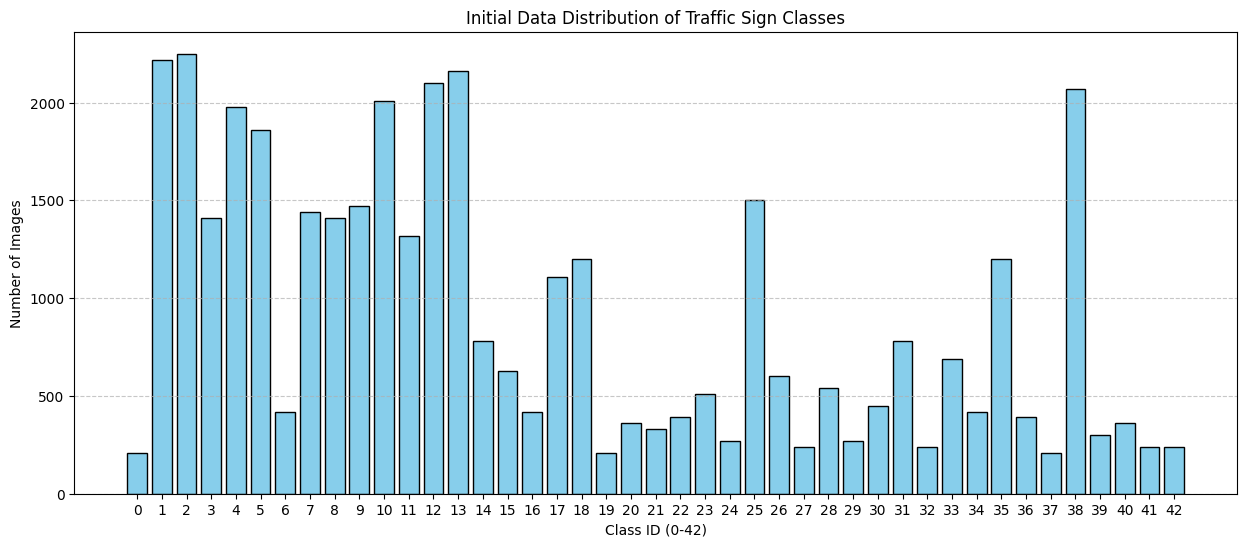

In [39]:
train_path = os.path.join(os.getcwd(), 'data', 'Train')
folders = os.listdir(train_path)

# Dictionary to store counts
class_counts = []
class_names = []

for folder in range(43):
    path = os.path.join(train_path, str(folder))
    images = os.listdir(path)
    class_counts.append(len(images))
    class_names.append(folder)

# Plotting the distribution
plt.figure(figsize=(15, 6))
plt.bar(class_names, class_counts, color='skyblue', edgecolor='black')
plt.xlabel('Class ID (0-42)')
plt.ylabel('Number of Images')
plt.title('Initial Data Distribution of Traffic Sign Classes')
plt.xticks(range(0, 43))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Data Preparation and Preprocessing

In [40]:
data = []     # Empty list to store the pixel data of every image.
labels = []   # Empty list to store the category ID (0-42) for each image.
classes = 43  # The total number of unique traffic sign types in the dataset.
cur_path = os.getcwd() # Gets the current path 

In [41]:
for i in range(classes): # Loop 43 times, once for each folder/category.
    # 'data' and 'Train' must match your folder names exactly
    path = os.path.join(cur_path, 'data', 'Train', str(i)) # Builds the path to the folder of class 'i'.
    images = os.listdir(path) # Gets a list of all filenames in that folder.
    for a in images: # Loop through every image in the folder.
        try:
            image = Image.open(path + '\\'+ a) # Open the image file.
            image = image.resize((48,48))      # Force the image to be 48x48 pixels (standardization).
            # image = image.resize((30,30))      # Force the image to be 30x30 pixels (standardization).
            image = np.array(image)            # Convert the 48x48 image into a numerical array.
            data.append(image)                 # Add the numbers to our 'data' list.
            labels.append(i)                   # Record that this image belongs to class 'i'.
        except Exception as e:
            print(e) # Skips files that are corrupted or not images.

## Converting lists into numpy arrays

In [42]:
data = np.array(data)
labels = np.array(labels)

## Normalizing pixel values to a range of 0 to 1

In [43]:
data = data.astype('float32') / 255.0

In [44]:
print(data.shape, labels.shape)

(39209, 48, 48, 3) (39209,)


# Save Labels & Data for future use

In [45]:
if not os.path.exists('training'):
    os.mkdir('training')

np.save('./training/data', data)
np.save('./training/target', labels)

# DATA SPLITTING & AUGMENTATION

In [46]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=0)
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)


# DATA AUGMENTATION: Creating a generator to artificially expand the dataset

In [47]:
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    fill_mode="nearest"
)

# CNN ARCHITECTURE

In [48]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- SECTION 4: TRAINING WITH AUGMENTATION ---
batch_size = 32
epochs = 20
history = model.fit(
    aug.flow(X_train, y_train, batch_size=batch_size),
    validation_data=(X_test, y_test),
    epochs=epochs
)

model.save("./training/TSR_Augmented.h5")

c:\USJ Lectures\Third_Year\SEM6\DL\DL_mini\Traffic_Sign_Classifier\tsr_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 62s 59ms/step - accuracy: 0.4537 - loss: 1.8579 - val_accuracy: 0.9035 - val_loss: 0.3472
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 105s 108ms/step - accuracy: 0.8059 - loss: 0.6097 - val_accuracy: 0.9804 - val_loss: 0.0854
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 94s 96ms/step - accuracy: 0.8958 - loss: 0.3412 - val_accuracy: 0.9893 - val_loss: 0.0409
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 89s 91ms/step - accuracy: 0.9297 - loss: 0.2331 - val_accuracy: 0.9925 - val_loss: 0.0315
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 123s 126ms/step - accuracy: 0.9412 - loss: 0.1967 - val_accuracy: 0.9931 - val_loss: 0.0229
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 90s 91ms/step - accuracy: 0.9533 - loss: 0.1612 - val_accuracy: 0.9943 - val_loss: 0.0215
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 75s 76ms/step - accuracy: 0.9559 - loss: 0.1476 - val_accuracy: 0.9945 - val_loss: 0.0198
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 109s 111ms/step - accuracy: 0.9628 - loss: 0.1

# TESTING

In [49]:
def testing(testcsv):
    y_test_df = pd.read_csv(testcsv) # This reads the CSV from 'data/Test.csv'
    labels = y_test_df["ClassId"].values
    imgs = y_test_df["Path"].values
    data_list = []
    
    for img in imgs:
        # Since images are in 'data/Test/...' and the CSV path is 'Test/...',
        # we combine 'data' + 'Test/...' to get the correct path.
        image_path = os.path.join('data', img) 
        image = Image.open(image_path)
        image = image.resize((48,48))
        # image = image.resize((30,30))
        data_list.append(np.array(image))
        
    X_test_data = np.array(data_list)
    return X_test_data.astype('float32') / 255.0, labels

# UPDATED: Path changed to 'data/Test.csv'
X_test_final, label_actual = testing('data/Test.csv') 

Y_pred = np.argmax(model.predict(X_test_final), axis=-1)

from sklearn.metrics import accuracy_score
print("Final Augmented Test Accuracy:", accuracy_score(label_actual, Y_pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step
Final Augmented Test Accuracy: 0.9785431512272368


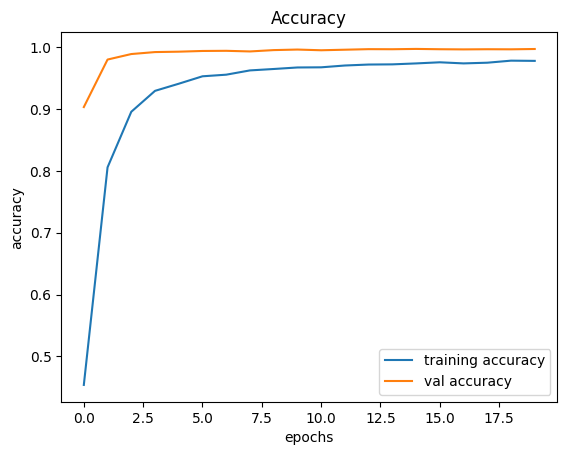

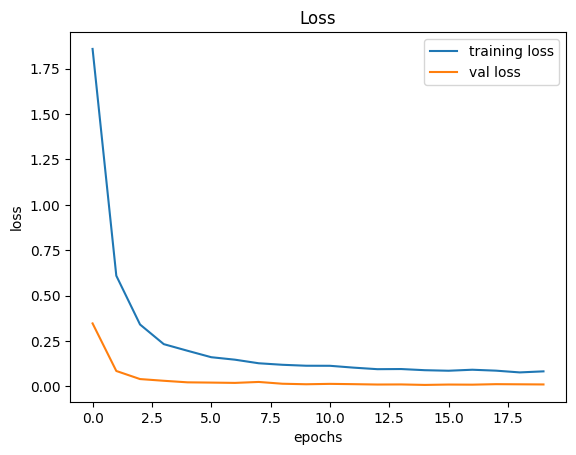

In [50]:
# --- SECTION 6: PLOTTING PERFORMANCE ---

# Accuracy plot
plt.figure(0)
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

# Loss plot
plt.figure(1)
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()